# 03 Baseline Model

Objective: train a Linear Regression baseline model to predict `ClosePrice`.

This notebook uses the cleaned data and rolling-origin split plan from `02_preprocessing.ipynb`:
- compare training windows `X = 3, 6, 9` on the same historical evaluation months
- fit preprocessing and outlier thresholds inside each training cutoff only
- select the most stable training window using historical performance
- evaluate the final selected baseline once on the latest test month

Experiment design:
- historical evaluation: `2026-03`, `2026-04`
- final test: `2026-05`
- metrics: R², MAE, RMSE, MAPE, MdAPE


## 0. Setup


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
SPLIT_DIR = PROCESSED_DATA_DIR / "splits"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "week4_baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLEANED_CSV = PROCESSED_DATA_DIR / "crmls_week3_cleaned.csv"
SPLIT_PLAN_CSV = PROCESSED_DATA_DIR / "crmls_week3_split_plan.csv"
TEST_CSV = SPLIT_DIR / "test_latest_month_cleaned.csv"

print(f"Cleaned data: {CLEANED_CSV}")
print(f"Split directory: {SPLIT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


Cleaned data: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/data/processed/crmls_week3_cleaned.csv
Split directory: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/data/processed/splits
Output directory: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week4_baseline


## 1. Load Preprocessed Data and Split Plan


In [2]:
clean_df = pd.read_csv(CLEANED_CSV, low_memory=False)
split_plan = pd.read_csv(SPLIT_PLAN_CSV, dtype={"split_type": "string", "eval_month": "string"})

if "CloseDate" in clean_df.columns:
    clean_df["CloseDate"] = pd.to_datetime(clean_df["CloseDate"], errors="coerce")
if "close_month" in clean_df.columns:
    clean_df["close_month"] = pd.PeriodIndex(clean_df["close_month"], freq="M")

required_split_types = {"historical_eval", "final_test_candidate"}
assert required_split_types.issubset(set(split_plan["split_type"])), "Split plan is missing required split types."
assert clean_df["ClosePrice"].notna().all(), "ClosePrice should not contain missing values."
assert (clean_df["ClosePrice"] > 0).all(), "ClosePrice should be positive after preprocessing."

historical_plan = (
    split_plan[split_plan["split_type"] == "historical_eval"]
    .copy()
    .sort_values(["X_train_months", "eval_month"])
)
final_plan = split_plan[split_plan["split_type"] == "final_test_candidate"].copy()

candidate_windows = sorted(historical_plan["X_train_months"].astype(int).unique().tolist())
historical_eval_months = sorted(historical_plan["eval_month"].astype(str).unique().tolist())

display(split_plan)
print(f"Cleaned data shape: {clean_df.shape}")
print(f"Candidate windows: {candidate_windows}")
print(f"Historical evaluation months: {historical_eval_months}")


,split_type,X_train_months,train_month_start,train_month_end,train_months,eval_month,train_rows,eval_rows
0,historical_eval,3,2025-12,2026-02,"2025-12, 2026-01, 2026-02",2026-03,26473,11169
1,historical_eval,3,2026-01,2026-03,"2026-01, 2026-02, 2026-03",2026-04,27196,12025
2,final_test_candidate,3,2026-02,2026-04,"2026-02, 2026-03, 2026-04",2026-05,31736,12024
3,historical_eval,6,2025-09,2026-02,"2025-09, 2025-10, 2025-11, 2025-12, 2026-01, 2...",2026-03,59662,11169
4,historical_eval,6,2025-10,2026-03,"2025-10, 2025-11, 2025-12, 2026-01, 2026-02, 2...",2026-04,59382,12025
5,final_test_candidate,6,2025-11,2026-04,"2025-11, 2025-12, 2026-01, 2026-02, 2026-03, 2...",2026-05,59387,12024
6,historical_eval,9,2025-06,2026-02,"2025-06, 2025-07, 2025-08, 2025-09, 2025-10, 2...",2026-03,94906,11169
7,historical_eval,9,2025-07,2026-03,"2025-07, 2025-08, 2025-09, 2025-10, 2025-11, 2...",2026-04,94383,12025
8,final_test_candidate,9,2025-08,2026-04,"2025-08, 2025-09, 2025-10, 2025-11, 2025-12, 2...",2026-05,94298,12024


Cleaned data shape: (153758, 46)
Candidate windows: [3, 6, 9]
Historical evaluation months: ['2026-03', '2026-04']


## 2. Define Model Features

These feature groups mirror `02_preprocessing.ipynb`. Leakage fields such as IDs, close date, source file, ListPrice-family fields, and post-close fields are excluded from model inputs.


In [3]:
target = "ClosePrice"
metadata_cols = ["ListingKey", "CloseDate", "close_month", "source_file"]

continuous_numeric_cols = [
    "LivingArea",
    "LotSizeSquareFeet",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "AssociationFee",
]

count_numeric_cols = [
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "GarageSpaces",
    "ParkingTotal",
    "Stories",
]

numeric_cols = continuous_numeric_cols + count_numeric_cols

boolean_cols = [
    "ViewYN",
    "PoolPrivateYN",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN",
]

categorical_cols = [
    "City",
    "CountyOrParish",
    "PostalCode",
    "MLSAreaMajor",
    "Levels",
    "Flooring",
    "HighSchoolDistrict",
]

flag_cols = [
    col for col in clean_df.columns
    if col.endswith("_missing") or col == "invalid_coordinates_flag"
]

numeric_cols = [col for col in numeric_cols if col in clean_df.columns]
boolean_cols = [col for col in boolean_cols if col in clean_df.columns]
categorical_cols = [col for col in categorical_cols if col in clean_df.columns]
flag_cols = [col for col in flag_cols if col in clean_df.columns]

feature_cols = numeric_cols + categorical_cols + boolean_cols + flag_cols

feature_summary = pd.DataFrame({
    "feature_group": ["numeric", "categorical", "boolean", "missing_or_quality_flags", "total_raw_model_features"],
    "n_features": [len(numeric_cols), len(categorical_cols), len(boolean_cols), len(flag_cols), len(feature_cols)],
})

display(feature_summary)


,feature_group,n_features
0,numeric,11
1,categorical,7
2,boolean,5
3,missing_or_quality_flags,17
4,total_raw_model_features,40


## 3. Build Preprocessing and Model Pipeline

Every cutoff fits its own preprocessing pipeline on training data only. The one-hot output is kept sparse to avoid unnecessary memory use with high-cardinality location fields.


In [4]:
def make_onehot_encoder():
    """Compatible with newer and older scikit-learn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def build_preprocessing_pipeline(numeric_features, categorical_features, boolean_features, flag_features):
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")),
        ("onehot", make_onehot_encoder()),
    ])
    boolean_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])
    flag_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
            ("bool", boolean_pipeline, boolean_features),
            ("flag", flag_pipeline, flag_features),
        ],
        remainder="drop",
        sparse_threshold=0.3,
        verbose_feature_names_out=True,
    )


def build_baseline_model():
    return Pipeline(steps=[
        ("preprocess", build_preprocessing_pipeline(
            numeric_features=numeric_cols,
            categorical_features=categorical_cols,
            boolean_features=boolean_cols,
            flag_features=flag_cols,
        )),
        ("model", LinearRegression()),
    ])


## 4. Define Outlier and Evaluation Functions

ClosePrice outlier bounds are learned from the training data only using the 0.5th and 99.5th percentiles, then applied unchanged to the evaluation or test month.


In [5]:
def load_split_file(path):
    df = pd.read_csv(path, low_memory=False)
    if "CloseDate" in df.columns:
        df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
    if "close_month" in df.columns:
        df["close_month"] = pd.PeriodIndex(df["close_month"], freq="M")
    return df


def apply_train_price_bounds(train_df, eval_df, target_col="ClosePrice", lower_q=0.005, upper_q=0.995):
    lower_bound = train_df[target_col].quantile(lower_q)
    upper_bound = train_df[target_col].quantile(upper_q)

    train_mask = train_df[target_col].between(lower_bound, upper_bound)
    eval_mask = eval_df[target_col].between(lower_bound, upper_bound)

    return (
        train_df.loc[train_mask].copy(),
        eval_df.loc[eval_mask].copy(),
        {
            "price_lower_bound": lower_bound,
            "price_upper_bound": upper_bound,
            "train_rows_before_outlier_filter": len(train_df),
            "train_rows_after_outlier_filter": int(train_mask.sum()),
            "eval_rows_before_outlier_filter": len(eval_df),
            "eval_rows_after_outlier_filter": int(eval_mask.sum()),
        },
    )


def regression_metrics(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)
    absolute_percentage_error = ((y_true - y_pred).abs() / y_true).replace([np.inf, -np.inf], np.nan) * 100

    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": absolute_percentage_error.mean(),
        "mdape": absolute_percentage_error.median(),
    }


## 5. Rolling-Origin Backtest

Compare `X = 3, 6, 9` on the same historical evaluation months. This checks whether a longer window is genuinely more stable instead of only looking good on one cutoff.


In [6]:
def rolling_train_path(x, eval_month):
    return SPLIT_DIR / f"rolling_train_X{x}_eval_{eval_month}_cleaned.csv"


def rolling_eval_path(eval_month):
    return SPLIT_DIR / f"rolling_eval_{eval_month}_cleaned.csv"


def final_train_path(x):
    return SPLIT_DIR / f"final_train_X{x}_cleaned.csv"


def run_historical_fold(plan_row):
    x = int(plan_row["X_train_months"])
    eval_month = str(plan_row["eval_month"])

    train_df_raw = load_split_file(rolling_train_path(x, eval_month))
    eval_df_raw = load_split_file(rolling_eval_path(eval_month))
    train_df, eval_df, bound_info = apply_train_price_bounds(train_df_raw, eval_df_raw)

    pipeline = build_baseline_model()
    pipeline.fit(train_df[feature_cols], train_df[target])
    predictions = pipeline.predict(eval_df[feature_cols])

    return {
        "X_train_months": x,
        "eval_month": eval_month,
        "train_month_start": plan_row["train_month_start"],
        "train_month_end": plan_row["train_month_end"],
        "train_months": plan_row["train_months"],
        **bound_info,
        **regression_metrics(eval_df[target], predictions),
    }


backtest_results = pd.DataFrame(
    run_historical_fold(plan_row)
    for _, plan_row in historical_plan.iterrows()
).sort_values(["X_train_months", "eval_month"])

backtest_results.to_csv(OUTPUT_DIR / "rolling_origin_results.csv", index=False)
backtest_results.to_csv(OUTPUT_DIR / "validation_window_results.csv", index=False)

display(backtest_results.round(4))


,X_train_months,eval_month,train_month_start,train_month_end,train_months,price_lower_bound,price_upper_bound,train_rows_before_outlier_filter,train_rows_after_outlier_filter,eval_rows_before_outlier_filter,eval_rows_after_outlier_filter,r2,mae,rmse,mape,mdape
0,3,2026-03,2025-12,2026-02,"2025-12, 2026-01, 2026-02",180000.0,8984200.0,26473,26208,11169,11042,0.8042,245058.6539,418947.4967,23.6319,17.1383
1,3,2026-04,2026-01,2026-03,"2026-01, 2026-02, 2026-03",180000.0,9301250.0,27196,26925,12025,11920,0.8133,260317.5393,448930.8504,24.6120,16.7486
2,6,2026-03,2025-09,2026-02,"2025-09, 2025-10, 2025-11, 2025-12, 2026-01, 2...",185000.0,8913900.0,59662,59067,11169,11039,0.8258,231747.4326,395187.6973,22.2289,16.1259
3,6,2026-04,2025-10,2026-03,"2025-10, 2025-11, 2025-12, 2026-01, 2026-02, 2...",180000.0,9127375.0,59382,58793,12025,11914,0.8249,246685.5343,428348.3030,22.9368,16.0646
4,9,2026-03,2025-06,2026-02,"2025-06, 2025-07, 2025-08, 2025-09, 2025-10, 2...",187000.0,8814250.0,94906,93957,11169,11036,0.8293,228394.1779,391154.5496,21.9026,15.7813
5,9,2026-04,2025-07,2026-03,"2025-07, 2025-08, 2025-09, 2025-10, 2025-11, 2...",185000.0,9000000.0,94383,93449,12025,11908,0.8285,241854.3166,418742.1526,22.4597,15.5232


In [7]:
window_summary = (
    backtest_results
    .groupby("X_train_months", as_index=False)
    .agg(
        n_cutoffs=("eval_month", "nunique"),
        mean_r2=("r2", "mean"),
        std_r2=("r2", "std"),
        min_r2=("r2", "min"),
        max_r2=("r2", "max"),
        mean_mae=("mae", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_mape=("mape", "mean"),
        mean_mdape=("mdape", "mean"),
        std_mdape=("mdape", "std"),
    )
    .sort_values(["mean_r2", "std_r2", "mean_mdape"], ascending=[False, True, True])
)

window_summary.to_csv(OUTPUT_DIR / "training_window_summary.csv", index=False)
display(window_summary.round(4))


,X_train_months,n_cutoffs,mean_r2,std_r2,min_r2,max_r2,mean_mae,mean_rmse,mean_mape,mean_mdape,std_mdape
2,9,2,0.8289,0.0006,0.8285,0.8293,235124.2473,404948.3511,22.1812,15.6522,0.1825
1,6,2,0.8253,0.0006,0.8249,0.8258,239216.4834,411768.0001,22.5828,16.0952,0.0434
0,3,2,0.8087,0.0064,0.8042,0.8133,252688.0966,433939.1735,24.1220,16.9435,0.2756


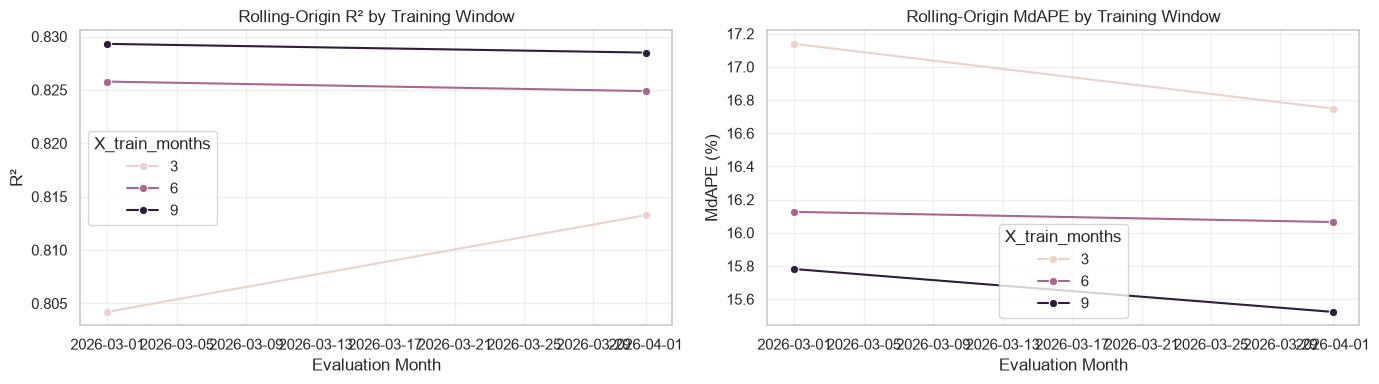

In [8]:
plot_df = backtest_results.copy()
plot_df["eval_month_date"] = pd.to_datetime(plot_df["eval_month"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.lineplot(data=plot_df, x="eval_month_date", y="r2", hue="X_train_months", marker="o", ax=axes[0])
axes[0].set_title("Rolling-Origin R² by Training Window")
axes[0].set_xlabel("Evaluation Month")
axes[0].set_ylabel("R²")
axes[0].grid(alpha=0.3)

sns.lineplot(data=plot_df, x="eval_month_date", y="mdape", hue="X_train_months", marker="o", ax=axes[1])
axes[1].set_title("Rolling-Origin MdAPE by Training Window")
axes[1].set_xlabel("Evaluation Month")
axes[1].set_ylabel("MdAPE (%)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Select Training Window

Select the candidate with the highest mean historical R². If windows are very close, prefer lower R² variability and lower MdAPE.


In [9]:
selected_summary = window_summary.iloc[0]
selected_x = int(selected_summary["X_train_months"])
selected_plan = final_plan.loc[final_plan["X_train_months"].astype(int) == selected_x].iloc[0]

selection_summary = pd.DataFrame([{
    "selected_X_train_months": selected_x,
    "selection_basis": "highest_mean_historical_r2_with_rolling_origin_check",
    "historical_eval_months": ", ".join(historical_eval_months),
    "mean_r2": selected_summary["mean_r2"],
    "std_r2": selected_summary["std_r2"],
    "mean_mdape": selected_summary["mean_mdape"],
    "std_mdape": selected_summary["std_mdape"],
    "final_train_months": selected_plan["train_months"],
    "final_test_month": selected_plan["eval_month"],
}])

display(selection_summary)


,selected_X_train_months,selection_basis,historical_eval_months,mean_r2,std_r2,mean_mdape,std_mdape,final_train_months,final_test_month
0,9,highest_mean_historical_r2_with_rolling_origin...,"2026-03, 2026-04",0.828902,0.000578,15.652233,0.182507,"2025-08, 2025-09, 2025-10, 2025-11, 2025-12, 2...",2026-05


## 7. Final Test Evaluation

Train the selected `X`-month baseline on the months immediately before the final test month, then evaluate once on `2026-05`.


In [10]:
test_df_raw = load_split_file(TEST_CSV)
final_train_df_raw = load_split_file(final_train_path(selected_x))

final_train_df, final_test_df, final_bound_info = apply_train_price_bounds(final_train_df_raw, test_df_raw)

final_model = build_baseline_model()
final_model.fit(final_train_df[feature_cols], final_train_df[target])
final_predictions = final_model.predict(final_test_df[feature_cols])
final_metrics = regression_metrics(final_test_df[target], final_predictions)

final_results_df = pd.DataFrame([{
    "model": "LinearRegression",
    "target": target,
    "selected_X_train_months": selected_x,
    "selection_basis": "highest_mean_historical_r2_with_rolling_origin_check",
    "historical_mean_r2": selected_summary["mean_r2"],
    "historical_std_r2": selected_summary["std_r2"],
    "historical_mean_mdape": selected_summary["mean_mdape"],
    "final_train_month_start": selected_plan["train_month_start"],
    "final_train_month_end": selected_plan["train_month_end"],
    "final_train_months": selected_plan["train_months"],
    "test_month": selected_plan["eval_month"],
    **final_bound_info,
    "test_r2": final_metrics["r2"],
    "test_mae": final_metrics["mae"],
    "test_rmse": final_metrics["rmse"],
    "test_mape": final_metrics["mape"],
    "test_mdape": final_metrics["mdape"],
}])

final_results_df.to_csv(OUTPUT_DIR / "final_test_results.csv", index=False)
display(final_results_df)


,model,target,selected_X_train_months,selection_basis,historical_mean_r2,historical_std_r2,historical_mean_mdape,final_train_month_start,final_train_month_end,final_train_months,test_month,price_lower_bound,price_upper_bound,train_rows_before_outlier_filter,train_rows_after_outlier_filter,eval_rows_before_outlier_filter,eval_rows_after_outlier_filter,test_r2,test_mae,test_rmse,test_mape,test_mdape
0,LinearRegression,ClosePrice,9,highest_mean_historical_r2_with_rolling_origin...,0.828902,0.000578,15.652233,2025-08,2026-04,"2025-08, 2025-09, 2025-10, 2025-11, 2025-12, 2...",2026-05,185000.0,9150000.0,94298,93371,12024,11918,0.835885,240548.645032,408345.23668,22.151011,15.429121


## 8. Prediction Diagnostics

Save row-level predictions and summarize final-test errors by price band and county. These diagnostics help identify where the baseline underperforms despite a strong top-line R².


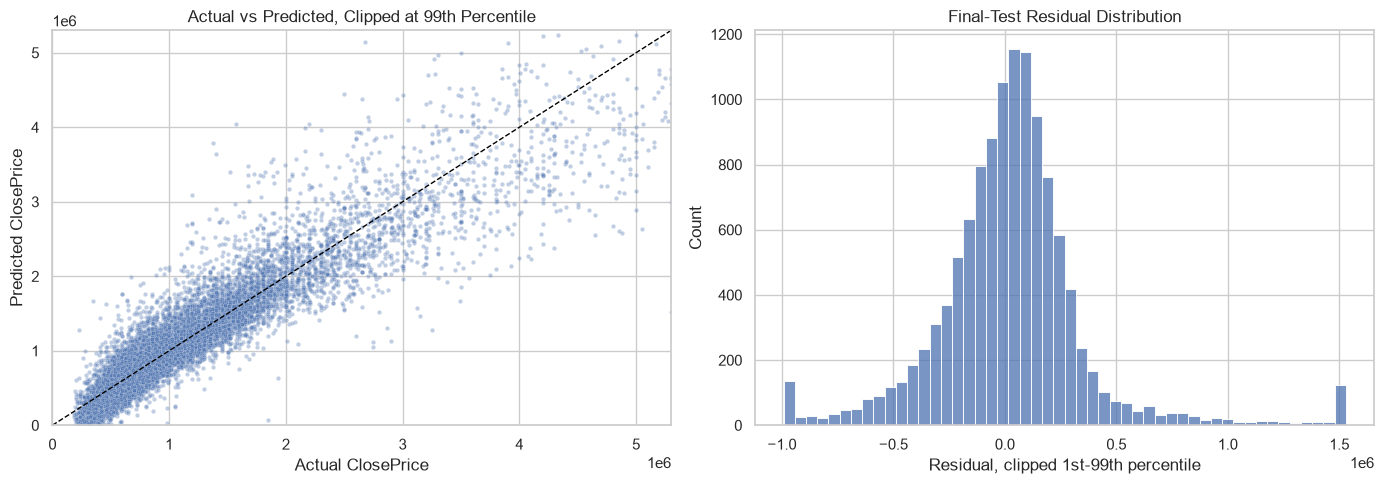

In [11]:
residuals = final_test_df[["ListingKey", "CloseDate", "close_month", "CountyOrParish", target]].copy()
residuals["predicted_ClosePrice"] = final_predictions
residuals["residual"] = residuals[target] - residuals["predicted_ClosePrice"]
residuals["absolute_error"] = residuals["residual"].abs()
residuals["absolute_percentage_error"] = residuals["absolute_error"] / residuals[target] * 100
residuals.to_csv(OUTPUT_DIR / "test_predictions_linear_regression.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
max_price = np.nanpercentile(final_test_df[target], 99)

sns.scatterplot(x=final_test_df[target], y=final_predictions, s=10, alpha=0.35, ax=axes[0])
axes[0].plot([0, max_price], [0, max_price], color="black", linestyle="--", linewidth=1)
axes[0].set_xlim(0, max_price)
axes[0].set_ylim(0, max_price)
axes[0].set_xlabel("Actual ClosePrice")
axes[0].set_ylabel("Predicted ClosePrice")
axes[0].set_title("Actual vs Predicted, Clipped at 99th Percentile")

sns.histplot(
    residuals["residual"].clip(residuals["residual"].quantile(0.01), residuals["residual"].quantile(0.99)),
    bins=50,
    ax=axes[1],
)
axes[1].set_xlabel("Residual, clipped 1st-99th percentile")
axes[1].set_title("Final-Test Residual Distribution")

plt.tight_layout()
plt.show()


In [12]:
error_by_price_band = residuals.copy()
error_by_price_band["price_band"] = pd.qcut(
    error_by_price_band[target],
    q=5,
    labels=["Q1_lowest", "Q2", "Q3", "Q4", "Q5_highest"],
)

price_band_summary = (
    error_by_price_band
    .groupby("price_band", observed=True)
    .agg(
        n_sales=(target, "size"),
        median_close_price=(target, "median"),
        r2=(target, lambda y: r2_score(y, error_by_price_band.loc[y.index, "predicted_ClosePrice"])),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
        mdape=("absolute_percentage_error", "median"),
    )
    .reset_index()
)

county_summary = (
    residuals
    .groupby("CountyOrParish")
    .agg(
        n_sales=(target, "size"),
        median_close_price=(target, "median"),
        mae=("absolute_error", "mean"),
        mape=("absolute_percentage_error", "mean"),
        mdape=("absolute_percentage_error", "median"),
    )
    .query("n_sales >= 100")
    .sort_values("mdape", ascending=False)
    .reset_index()
)

price_band_summary.to_csv(OUTPUT_DIR / "error_by_price_band.csv", index=False)
county_summary.to_csv(OUTPUT_DIR / "error_by_county.csv", index=False)

display(price_band_summary)
display(county_summary.head(15))


,price_band,n_sales,median_close_price,r2,mae,mape,mdape
0,Q1_lowest,2412,450962.0,-3.634730,154258.314105,37.111671,28.351945
1,Q2,2385,700000.0,-10.130328,160582.704505,23.181585,17.865364
2,Q3,2354,930000.0,-5.776094,166516.727986,17.701715,12.900757
3,Q4,2383,1350000.0,-3.012459,217348.518866,16.013251,11.585293
4,Q5_highest,2384,2379500.0,0.618573,504142.638210,16.512127,13.304927


,CountyOrParish,n_sales,median_close_price,mae,mape,mdape
0,Kern,124,400000.0,158957.463312,39.616110,31.941184
1,Merced,105,420000.0,130213.657989,31.464013,23.826766
2,Riverside,1784,637500.0,210768.204863,28.946985,23.189202
3,Butte,158,459000.0,149413.327269,31.250144,22.904960
4,San Bernardino,1166,554970.0,163374.190171,30.412941,21.089532
5,Monterey,147,975000.0,337222.727148,21.406872,15.858874
6,Contra Costa,596,962500.0,216998.016526,18.402898,14.106603
7,Los Angeles,2909,1050000.0,258348.015814,19.056970,13.913652
8,San Mateo,173,2100000.0,448810.250180,18.063134,13.790941
9,Alameda,611,1400000.0,270362.700644,17.753922,13.458276


## 9. Baseline Summary

The rolling-origin comparison selected `X=9`, which had the highest mean historical R² and low month-to-month variability. The final Linear Regression baseline was trained on `2025-08` through `2026-04` and evaluated once on `2026-05`.

This is still a baseline model. Future improvements should compare log-price targets, regularized linear models, tree-based models, richer location features, and more rolling-origin cutoffs.


In [13]:
baseline_summary = pd.concat([
    selection_summary.add_prefix("selection_"),
    final_results_df.add_prefix("final_"),
], axis=1)

display(baseline_summary.T.rename(columns={0: "value"}))

print(f"Selected X: {selected_x}")
print(f"Final test R²: {final_metrics['r2']:.4f}")
print(f"Final test MAE: ${final_metrics['mae']:,.0f}")
print(f"Final test MdAPE: {final_metrics['mdape']:.2f}%")
print(f"Saved outputs to: {OUTPUT_DIR}")


,value
selection_selected_X_train_months,9
selection_selection_basis,highest_mean_historical_r2_with_rolling_origin...
selection_historical_eval_months,"2026-03, 2026-04"
selection_mean_r2,0.828902
selection_std_r2,0.000578
selection_mean_mdape,15.652233
selection_std_mdape,0.182507
selection_final_train_months,"2025-08, 2025-09, 2025-10, 2025-11, 2025-12, 2..."
selection_final_test_month,2026-05
final_model,LinearRegression


Selected X: 9
Final test R²: 0.8359
Final test MAE: $240,549
Final test MdAPE: 15.43%
Saved outputs to: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week4_baseline
